# House Prices: Linear Regression Project

This notebook uses the Kaggle House Prices dataset to build a simple linear regression model. I kept the workflow beginner-friendly on purpose, so it is easy to follow and explain in class.

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score

# Make plots a little easier to read
plt.style.use('seaborn-v0_8-whitegrid')

## 1) Load the data

The CSV file should be in the same folder as this notebook. If I were doing this in Colab, I would upload `train.csv` first.

In [4]:
df = pd.read_csv('train.csv')

print('Data loaded successfully.')
print('Rows and columns:', df.shape)
df.head()

Data loaded successfully.
Rows and columns: (1460, 81)


,Id,MSSubClass,MSZoning,LotFrontage,LotArea,Street,Alley,LotShape,LandContour,Utilities,...,PoolArea,PoolQC,Fence,MiscFeature,MiscVal,MoSold,YrSold,SaleType,SaleCondition,SalePrice
0,1,60,RL,65.0,8450,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,NaN,NaN,0,2,2008,WD,Normal,208500
1,2,20,RL,80.0,9600,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,NaN,NaN,0,5,2007,WD,Normal,181500
2,3,60,RL,68.0,11250,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,9,2008,WD,Normal,223500
3,4,70,RL,60.0,9550,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,2,2006,WD,Abnorml,140000
4,5,60,RL,84.0,14260,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,12,2008,WD,Normal,250000


## 2) Basic data exploration

Here I am checking the shape, missing values, data types, and summary statistics. These are usually the first things I look at before modeling.

In [3]:
print('Shape:', df.shape)

print('\nData types:')
print(df.dtypes)

print('\nMissing values per column:')
missing_values = df.isna().sum().sort_values(ascending=False)
print(missing_values[missing_values > 0])

print('\nSummary statistics:')
df.describe()

Shape: (1460, 81)

Data types:
Id                 int64
MSSubClass         int64
MSZoning             str
LotFrontage      float64
LotArea            int64
                  ...   
MoSold             int64
YrSold             int64
SaleType             str
SaleCondition        str
SalePrice          int64
Length: 81, dtype: object

Missing values per column:
PoolQC          1453
MiscFeature     1406
Alley           1369
Fence           1179
MasVnrType       872
FireplaceQu      690
LotFrontage      259
GarageQual        81
GarageFinish      81
GarageType        81
GarageYrBlt       81
GarageCond        81
BsmtFinType2      38
BsmtExposure      38
BsmtCond          37
BsmtQual          37
BsmtFinType1      37
MasVnrArea         8
Electrical         1
dtype: int64

Summary statistics:


,Id,MSSubClass,LotFrontage,LotArea,OverallQual,OverallCond,YearBuilt,YearRemodAdd,MasVnrArea,BsmtFinSF1,...,WoodDeckSF,OpenPorchSF,EnclosedPorch,3SsnPorch,ScreenPorch,PoolArea,MiscVal,MoSold,YrSold,SalePrice
count,1460.000000,1460.000000,1201.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1452.000000,1460.000000,...,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000
mean,730.500000,56.897260,70.049958,10516.828082,6.099315,5.575342,1971.267808,1984.865753,103.685262,443.639726,...,94.244521,46.660274,21.954110,3.409589,15.060959,2.758904,43.489041,6.321918,2007.815753,180921.195890
std,421.610009,42.300571,24.284752,9981.264932,1.382997,1.112799,30.202904,20.645407,181.066207,456.098091,...,125.338794,66.256028,61.119149,29.317331,55.757415,40.177307,496.123024,2.703626,1.328095,79442.502883
min,1.000000,20.000000,21.000000,1300.000000,1.000000,1.000000,1872.000000,1950.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000,2006.000000,34900.000000
25%,365.750000,20.000000,59.000000,7553.500000,5.000000,5.000000,1954.000000,1967.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,5.000000,2007.000000,129975.000000
50%,730.500000,50.000000,69.000000,9478.500000,6.000000,5.000000,1973.000000,1994.000000,0.000000,383.500000,...,0.000000,25.000000,0.000000,0.000000,0.000000,0.000000,0.000000,6.000000,2008.000000,163000.000000
75%,1095.250000,70.000000,80.000000,11601.500000,7.000000,6.000000,2000.000000,2004.000000,166.000000,712.250000,...,168.000000,68.000000,0.000000,0.000000,0.000000,0.000000,0.000000,8.000000,2009.000000,214000.000000
max,1460.000000,190.000000,313.000000,215245.000000,10.000000,9.000000,2010.000000,2010.000000,1600.000000,5644.000000,...,857.000000,547.000000,552.000000,508.000000,480.000000,738.000000,15500.000000,12.000000,2010.000000,755000.000000


## 3) Choose a few meaningful features

I picked these features because they make sense for house prices:

- `OverallQual`: better quality usually means a more expensive house.
- `GrLivArea`: larger living space usually increases the price.
- `GarageCars`: a bigger garage often adds value.
- `TotalBsmtSF`: a larger basement can make the house more useful and valuable.
- `YearBuilt`: newer houses are often priced higher than older ones.

These are simple features, but they are still pretty reasonable for a first model.

In [5]:
features = ['OverallQual', 'GrLivArea', 'GarageCars', 'TotalBsmtSF', 'YearBuilt']
target = 'SalePrice'

data = df[features + [target]].copy()

# Simple missing-value handling: fill numeric feature gaps with the median.
# That keeps the notebook beginner-friendly and avoids dropping too many rows.
for column in features:
    data[column] = data[column].fillna(data[column].median())

# The target should not be missing, but this is a safe extra step.
data = data.dropna(subset=[target])

print('Selected data shape:', data.shape)
data.head()

Selected data shape: (1460, 6)


,OverallQual,GrLivArea,GarageCars,TotalBsmtSF,YearBuilt,SalePrice
0,7,1710,2,856,2003,208500
1,6,1262,2,1262,1976,181500
2,7,1786,2,920,2001,223500
3,7,1717,3,756,1915,140000
4,8,2198,3,1145,2000,250000


## 4) Split the data

I am using `train_test_split` so I can train on one part of the data and check the model on unseen data. That gives a more honest idea of performance.

In [6]:
X = data[features]
y = data[target]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

print('Training set shape:', X_train.shape)
print('Testing set shape:', X_test.shape)

Training set shape: (1168, 5)
Testing set shape: (292, 5)


## 5) Train the Linear Regression model

This is a straightforward model, so it is a good starting point for a university assignment. It will not be perfect, but it should show the basic idea clearly.

In [7]:
model = LinearRegression()
model.fit(X_train, y_train)

print('Model training finished.')

Model training finished.


## 6) Make predictions and evaluate the model

I am using RMSE and R² because they are common regression metrics. RMSE tells me roughly how far off the predictions are in house-price units, and R² gives a quick idea of how much of the price variation the model explains.

In [ ]:
y_pred = model.predict(X_test)

rmse = mean_squared_error(y_test, y_pred) ** 0.5
r2 = r2_score(y_test, y_pred)

print(f'RMSE: {rmse:,.2f}')
print(f'R² Score: {r2:.4f}')

results = pd.DataFrame({
    'Actual': y_test.values,
    'Predicted': y_pred
})
results.head()

RMSE: 39,763.30
R² Score: 0.7939


,Actual,Predicted
0,154500,142114.233962
1,325000,293935.140813
2,115000,122246.694253
3,159000,179899.246542
4,315500,288653.828812


## 7) Scatter plot: actual vs predicted

If the model is working well, the points should sit fairly close to the diagonal line. The more spread out the points are, the less accurate the model is.

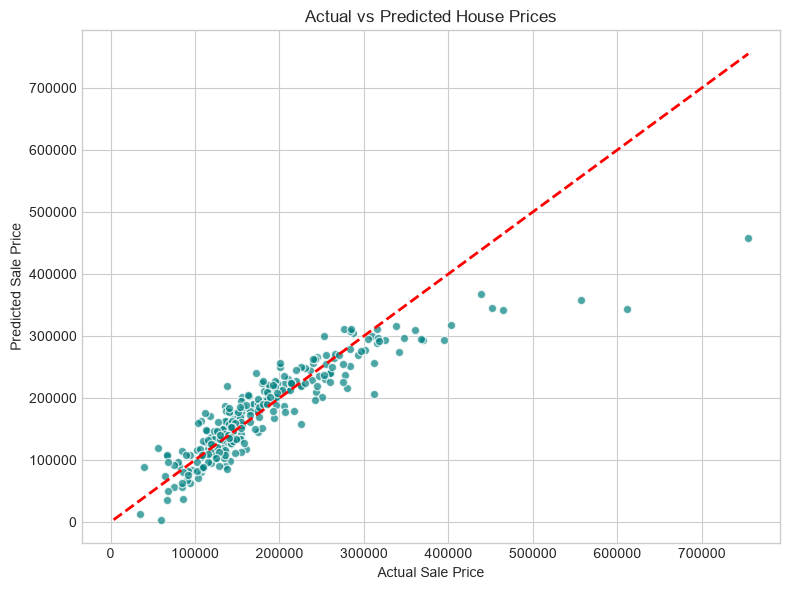

In [11]:
plt.figure(figsize=(8, 6))
plt.scatter(y_test, y_pred, alpha=0.7, color='teal', edgecolor='white')

min_value = min(y_test.min(), y_pred.min())
max_value = max(y_test.max(), y_pred.max())
plt.plot([min_value, max_value], [min_value, max_value], color='red', linestyle='--', linewidth=2)

plt.title('Actual vs Predicted House Prices')
plt.xlabel('Actual Sale Price')
plt.ylabel('Predicted Sale Price')
plt.tight_layout()
plt.show()

## 8) Conclusion

This model is a solid first attempt, but it is still pretty simple. If the scatter plot shows points close to the diagonal line, then the predictions are reasonably good. If the points are very spread out, then the model is missing a lot of the real pattern in the data.

Overall, I would expect this model to capture the basic trend that better and larger houses cost more, but it will not explain everything. A more advanced model with more features would probably do better.

### R² in plain English

R² is a number that tells you how well the model is keeping up with the real prices. If it is closer to 1, the model is doing a better job. If it is closer to 0, the model is not learning much from the data. A negative value would mean the model is doing worse than a very basic guess.